In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
%matplotlib inline
import matplotlib.pyplot as plt
import sys # sys.path

In [2]:
# Load the file using its relative path from your Jupyter home directory
df0 = pd.read_csv('Documents/Crosscheck_Nijsse_10_10.csv')

# Look at the first 5 rows to make sure it loaded correctly
df0.head()

,Unnamed: 0,Model,T_75-85,T_04-14,delta_T,F_75-85,F_04-14,delta_F,s,s_prime,TCR,e_prime,ECS,ECS_OG
0,0,AWI-CM-1-1-MR,0.644396,1.103605,0.459208,1.082141,1.822579,0.740438,5.010549,0.199579,2.300885,0.146994,3.476789,3.127920
1,1,BCC-CSM2-MR,0.539137,0.919598,0.380460,0.885838,1.491958,0.606120,6.120896,0.163375,2.328759,0.211099,4.580547,3.023299
2,2,BCC-ESM1,0.580120,0.991630,0.411510,0.889172,1.497574,0.608402,6.097943,0.163990,2.509367,0.179092,4.557585,3.338070
3,3,CAMS-CSM1-0,0.502208,0.860115,0.357907,1.154606,1.944627,0.790021,4.696078,0.212944,1.680759,0.171850,2.363397,2.300185
4,4,FGOALS-f3-L,0.594061,1.015834,0.421773,1.150959,1.938485,0.787526,4.710957,0.212271,1.986956,0.191631,3.208714,2.997235


In [3]:
# Removed unnanmed:0 column, artifact from the data import process
df=df0.drop(columns=['Unnamed: 0'])
df

,Model,T_75-85,T_04-14,delta_T,F_75-85,F_04-14,delta_F,s,s_prime,TCR,e_prime,ECS,ECS_OG
0,AWI-CM-1-1-MR,0.644396,1.103605,0.459208,1.082141,1.822579,0.740438,5.010549,0.199579,2.300885,0.146994,3.476789,3.127920
1,BCC-CSM2-MR,0.539137,0.919598,0.380460,0.885838,1.491958,0.606120,6.120896,0.163375,2.328759,0.211099,4.580547,3.023299
2,BCC-ESM1,0.580120,0.991630,0.411510,0.889172,1.497574,0.608402,6.097943,0.163990,2.509367,0.179092,4.557585,3.338070
3,CAMS-CSM1-0,0.502208,0.860115,0.357907,1.154606,1.944627,0.790021,4.696078,0.212944,1.680759,0.171850,2.363397,2.300185
4,FGOALS-f3-L,0.594061,1.015834,0.421773,1.150959,1.938485,0.787526,4.710957,0.212271,1.986956,0.191631,3.208714,2.997235
5,CanESM5,0.907569,1.551424,0.643855,1.054561,1.776127,0.721567,5.141591,0.194492,3.310439,0.148855,6.526565,5.620691
6,CNRM-CM6-1,0.797240,1.362296,0.565056,1.021113,1.719794,0.698681,5.310009,0.188324,3.000453,0.155152,5.613839,4.898427
7,CNRM-ESM2-1,0.732158,1.250518,0.518360,0.863430,1.454219,0.590789,6.279742,0.159242,3.255170,0.150195,6.369094,4.746849
8,ACCESS-CM2,0.754268,1.288897,0.534629,0.950884,1.601511,0.650627,5.702191,0.175371,3.048556,0.162114,6.027341,4.698697
9,ACCESS-ESM1-5,0.611906,1.041334,0.429428,0.810496,1.365065,0.554569,6.689880,0.149480,2.872823,0.194862,6.526228,3.857135


In [4]:
# Calculate the mean of ECS and ECS_OG
mean_ECS = df['ECS'].mean()
mean_ECS_OG = df['ECS_OG'].mean()

print(f"Mean ECS: {mean_ECS}")
print(f"Mean ECS_OG: {mean_ECS_OG}")

Mean ECS: 5.149867448336298
Mean ECS_OG: 3.7983210149674704


In [5]:
# Create arrays to run data through 'plt.pcolormesh(Trange,erange,np.log(y))'

model=np.array(df.iloc[:,0]) # model names
s_p=np.array(df.iloc[:,8]) # s_prime - model values
ECS_emerge=np.array(df.iloc[:,11]) # ECS - model values
d_T=np.array(df.iloc[:,3]) # T - model values
e_p=np.array(df.iloc[:,10]) # e_prime - model values

# 11/1/24 ECS from one percent co2 experiment
ECS_std=np.array(df.iloc[:,12])

print(f'e:{e_p}')
print(f't:{d_T}')

e:[0.14699369 0.21109875 0.17909244 0.17184965 0.19163111 0.14885475
 0.15515183 0.15019542 0.16211352 0.19486184 0.1150166  0.1412466
 0.13401912 0.21525617 0.15384794 0.12634257 0.17806568 0.14910108
 0.17522064 0.14609206 0.19497511 0.29237649 0.17784756 0.13873571
 0.22965128 0.22622072 0.29444165 0.19397079 0.16629366 0.12832584
 0.20153345]
t:[0.45920815 0.38046044 0.41151038 0.35790693 0.42177323 0.64385506
 0.56505608 0.51836046 0.5346289  0.42942811 0.66770359 0.57449612
 0.56261097 0.28860235 0.2977963  0.58690171 0.35440376 0.62065826
 0.58636857 0.62559185 0.40246134 0.36948972 0.41613537 0.34713483
 0.49285875 0.53483768 0.32811287 0.46168536 0.3700463  0.60752305
 0.43305388]


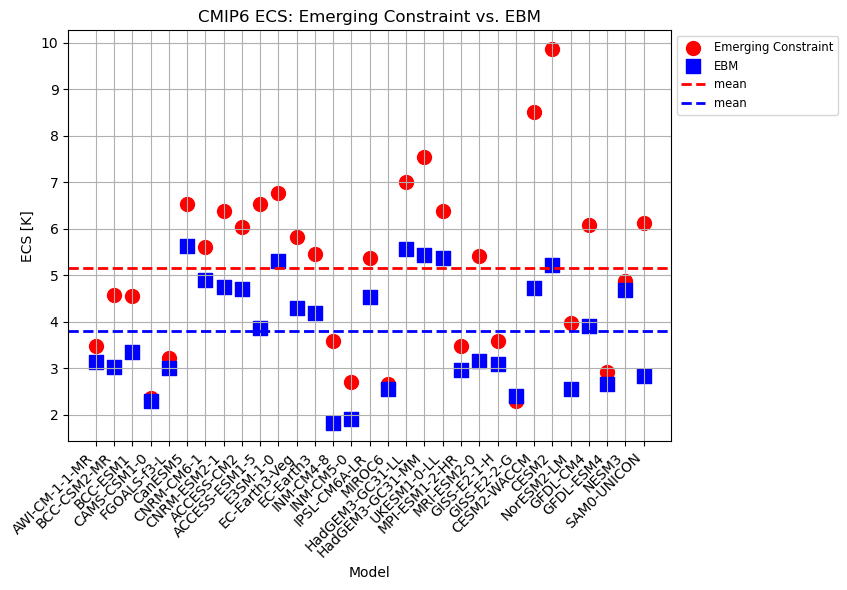

In [6]:
# Your calculated means:
mean_ECS = 5.149867448336298
mean_ECS_OG = 3.7983210149674704

# Assume df contains columns 'Model', 'ECS', and 'ECS_OG'
# For example, print(df.columns) might yield:
# Index(['Model', ..., 'ECS', 'ECS_OG'], dtype='object')

# Get the list of model names and assign x-axis positions.
models = df['Model'].tolist()
x = np.arange(len(models))  # one x-position per model

plt.figure(figsize=(10, 6))

# Plot the ECS values (emerging constraint) with blue circles.
plt.scatter(x, df['ECS'], color='red', marker='o', s=100, label=r"Emerging Constraint")

# Plot the ECS_OG values (original ECS) with orange squares.
plt.scatter(x, df['ECS_OG'], color='blue', marker='s', s=100, label='EBM')

# Add horizontal dashed lines for the mean values.
plt.axhline(mean_ECS, color='red', linestyle='--', linewidth=2, label= 'mean')
plt.axhline(mean_ECS_OG, color='blue', linestyle='--', linewidth=2 ,label='mean')

# Set the x-axis ticks and labels to the model names.
plt.xticks(x, models, rotation=45, ha='right')

plt.xlabel("Model")
plt.ylabel("ECS [K]")
plt.title(r"CMIP6 ECS: Emerging Constraint vs. EBM")
# Place the legend outside the plot area
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to make room for the legend

plt.savefig("ECS_comparison_with_means.png", dpi=600)
plt.show()

In [7]:
def ECS_partial_T(T, s_prime, e_prime):
    result = s_prime / (T * e_prime - s_prime)**2
    return result

def ECS_partial_e(T, s_prime, e_prime):
    result = T**2 / (T * e_prime - s_prime)**2
    return result

def ECS_partial_s(T, s_prime, e_prime):
    result = -T / (T * e_prime - s_prime)**2  # Corrected sign and terms 4-6-2025
    return result

Test functions on CSIRO Model

In [9]:
print(f'CSIRO MODEL')
print(f'ECS partial derivative w.r.t e_prime:{ECS_partial_T(0.252,0.083,0.237)}[K²]') 
print(f'ECS partial derivative w.r.t T:{ECS_partial_e(0.252,0.083,0.237)}[unitless]') 
print(f'ECS per unit s_prime:{ECS_partial_s(0.252,0.083,0.237)}[k]')

CSIRO MODEL
ECS partial derivative w.r.t e_prime:153.2009277641456[K²]
ECS partial derivative w.r.t T:117.21532188836508[unitless]
ECS per unit s_prime:-465.1401662236709[k]


In [10]:
# Loop through each model and calculate the partial derivatives
for i in range(len(model)):
    print(f'Model: {model[i]}')
    
    # Extract parameters for the current model
    s_prime = s_p[i]
    e_prime = e_p[i]
    delta_T = d_T[i]
    
    # Calculate partial derivatives
    partial_T = ECS_partial_T(delta_T, s_prime, e_prime)
    partial_e = ECS_partial_e(delta_T, s_prime, e_prime)
    partial_s = ECS_partial_s(delta_T, s_prime, e_prime)
    
    # Print the results for the current model
    print(f'ECS partial derivative w.r.t e_prime: {partial_T} [K²]')
    print(f'ECS partial derivative w.r.t T: {partial_e} [unitless]')
    print(f'ECS partial derivative w.r.t s_prime: {partial_s} [K]')
    print('-' * 60) # create a barrier

Model: AWI-CM-1-1-MR
ECS partial derivative w.r.t e_prime: 11.440691224052737 [K²]
ECS partial derivative w.r.t T: 12.088064753179047 [unitless]
ECS partial derivative w.r.t s_prime: -26.32371537546179 [K]
------------------------------------------------------------
Model: BCC-CSM2-MR
ECS partial derivative w.r.t e_prime: 23.68103185146469 [K²]
ECS partial derivative w.r.t T: 20.981408532031995 [unitless]
ECS partial derivative w.r.t s_prime: -55.14741155515808 [K]
------------------------------------------------------------
Model: BCC-ESM1
ECS partial derivative w.r.t e_prime: 20.115208701534208 [K²]
ECS partial derivative w.r.t T: 20.77157794801815 [unitless]
ECS partial derivative w.r.t s_prime: -50.476437237344626 [K]
------------------------------------------------------------
Model: CAMS-CSM1-0
ECS partial derivative w.r.t e_prime: 9.285343915309657 [K²]
ECS partial derivative w.r.t T: 5.585647359068772 [unitless]
ECS partial derivative w.r.t s_prime: -15.606423941529654 [K]
----

In [11]:
# Loop through each model and calculate the partial derivatives
for i in range(len(model)):
    print(f'Model: {model[i]}')
    
    # Extract parameters for the current model
    s_prime = s_p[i]
    e_prime = e_p[i]
    delta_T = d_T[i]
    
    # Calculate partial derivatives
    partial_T = ECS_partial_T(delta_T, s_prime, e_prime)
    partial_e = ECS_partial_e(delta_T, s_prime, e_prime)
    partial_s = ECS_partial_s(delta_T, s_prime, e_prime)
    
    # Print the results for the current model
    print(f'ECS partial derivative w.r.t e_prime: {partial_T} [K²]')
    print(f'ECS partial derivative w.r.t T: {partial_e} [unitless]')
    print(f'ECS partial derivative w.r.t s_prime: {partial_s} [K]')
    
    # If the model is CESM2 (or contains "CESM2"), calculate the percentage contributions.
    if "CESM2" in model[i]:
        total = abs(partial_T) + abs(partial_e) + abs(partial_s)
        # Calculate percentage contributions (using absolute values)
        perc_e_prime = abs(partial_T) / total * 100
        perc_T = abs(partial_e) / total * 100
        perc_s_prime = abs(partial_s) / total * 100
        
        print("Percentage contributions for CESM2:")
        print(f"  Partial derivative w.r.t e_prime: {perc_e_prime:.2f}%")
        print(f"  Partial derivative w.r.t T: {perc_T:.2f}%")
        print(f"  Partial derivative w.r.t s_prime: {perc_s_prime:.2f}%")
    
    print('-' * 60)

Model: AWI-CM-1-1-MR
ECS partial derivative w.r.t e_prime: 11.440691224052737 [K²]
ECS partial derivative w.r.t T: 12.088064753179047 [unitless]
ECS partial derivative w.r.t s_prime: -26.32371537546179 [K]
------------------------------------------------------------
Model: BCC-CSM2-MR
ECS partial derivative w.r.t e_prime: 23.68103185146469 [K²]
ECS partial derivative w.r.t T: 20.981408532031995 [unitless]
ECS partial derivative w.r.t s_prime: -55.14741155515808 [K]
------------------------------------------------------------
Model: BCC-ESM1
ECS partial derivative w.r.t e_prime: 20.115208701534208 [K²]
ECS partial derivative w.r.t T: 20.77157794801815 [unitless]
ECS partial derivative w.r.t s_prime: -50.476437237344626 [K]
------------------------------------------------------------
Model: CAMS-CSM1-0
ECS partial derivative w.r.t e_prime: 9.285343915309657 [K²]
ECS partial derivative w.r.t T: 5.585647359068772 [unitless]
ECS partial derivative w.r.t s_prime: -15.606423941529654 [K]
----

In [12]:
# Lists to store partial derivatives
partial_T_list = []
partial_e_list = []
partial_s_list = []

# Lists to store percentage contributions for each model
perc_T_list = []
perc_e_list = []
perc_s_list = []

# Loop through each model
for i in range(len(model)):
    # Extract parameters
    s_prime = s_p[i]
    e_prime = e_p[i]
    delta_T = d_T[i]

    # Calculate partial derivatives
    partial_T = ECS_partial_T(delta_T, s_prime, e_prime)
    partial_e = ECS_partial_e(delta_T, s_prime, e_prime)
    partial_s = ECS_partial_s(delta_T, s_prime, e_prime)

    # Store partials
    partial_T_list.append(partial_T)
    partial_e_list.append(partial_e)
    partial_s_list.append(partial_s)

    # Calculate total derivative magnitude for normalization
    total = abs(partial_T) + abs(partial_e) + abs(partial_s)

    # Compute percent contributions (and store them)
    perc_T_list.append(abs(partial_T) / total * 100)
    perc_e_list.append(abs(partial_e) / total * 100)
    perc_s_list.append(abs(partial_s) / total * 100)

# Convert to arrays and compute averages
avg_perc_T = np.mean(perc_T_list)
avg_perc_e = np.mean(perc_e_list)
avg_perc_s = np.mean(perc_s_list)

# Print the results
print("Average percentage contributions across all models:")
print(f"  ∂ECS/∂T      : {avg_perc_T:.2f}%")
print(f"  ∂ECS/∂e′     : {avg_perc_e:.2f}%")
print(f"  ∂ECS/∂s′     : {avg_perc_s:.2f}%")

Average percentage contributions across all models:
  ∂ECS/∂T      : 21.43%
  ∂ECS/∂e′     : 25.17%
  ∂ECS/∂s′     : 53.40%


In [13]:
# Partial derivative values for model CESM2
p_e = 59.56117041917652    # partial derivative w.r.t. e_prime [K²]
p_T = 97.22851929788987    # partial derivative w.r.t. T [unitless]
p_s = -181.79070699610529  # partial derivative w.r.t. s_prime [K]

# Calculate total magnitude (using absolute values)
total = abs(p_e) + abs(p_T) + abs(p_s)

# Calculate percentage contributions
percent_e = abs(p_e) / total * 100
percent_T = abs(p_T) / total * 100
percent_s = abs(p_s) / total * 100

print("Percentage contributions for CESM2:")
print(f"Partial derivative w.r.t e_prime: {percent_e:.2f}%")
print(f"Partial derivative w.r.t T: {percent_T:.2f}%")
print(f"Partial derivative w.r.t s_prime: {percent_s:.2f}%")

Percentage contributions for CESM2:
Partial derivative w.r.t e_prime: 17.59%
Partial derivative w.r.t T: 28.72%
Partial derivative w.r.t s_prime: 53.69%


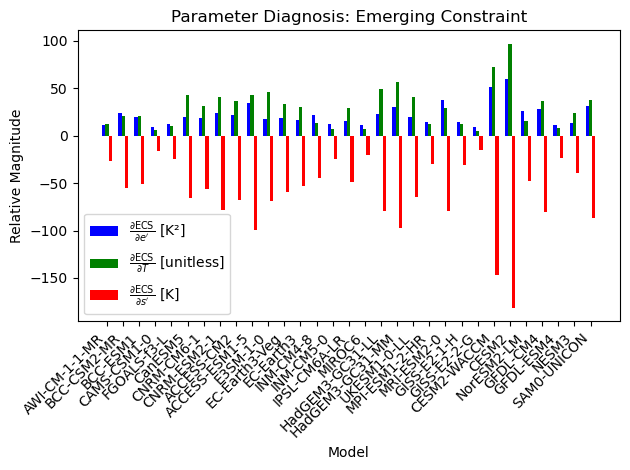

In [14]:
bar_width = 0.2
index = np.arange(len(model))  # Positions for the bars

fig, ax = plt.subplots()
bar1 = ax.bar(index, partial_T_list, bar_width, label=r"$\frac{\partial \mathrm{ECS}}{\partial e'}$ [K²]", color='blue')
bar2 = ax.bar(index + bar_width, partial_e_list, bar_width, label=r"$\frac{\partial \mathrm{ECS}}{\partial T}$ [unitless]", color='green')
bar3 = ax.bar(index + 2 * bar_width, partial_s_list, bar_width, label=r"$\frac{\partial \mathrm{ECS}}{\partial s'}$ [K]", color='red')

plt.xlabel('Model')
plt.ylabel('Relative Magnitude')
plt.title('Parameter Diagnosis: Emerging Constraint')
plt.xticks(index + bar_width, model, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('ECS_partial_derivatives_Model.png', dpi = 600)
plt.show()

In [17]:
# Read the CSV file that contains TCR values for both surface and deep ocean
df_tcr = pd.read_csv("Documents/Masters Thesis CSV/TCR_CMIP6.csv")

# Extract only the Model names and Surface TCR values
df_surface_tcr = df_tcr[['Model', 'Surface_TCR']]

# Display the table of surface TCR values
print(df_surface_tcr)

    Model  Surface_TCR
0       0     2.229827
1       1     1.906368
2       2     2.097153
3       3     1.771039
4       4     2.111575
5       5     3.180986
6       6     3.162920
7       7     2.874549
8       8     2.642708
9       9     2.693252
10     10     2.150404
11     11     3.140480
12     12     2.666949
13     13     2.646317
14     14     1.303369
15     15     1.449437
16     16     2.845949
17     18     1.869238
18     19     3.057487
19     20     2.893145
20     21     3.080223
21     22     2.025757
22     23     1.891276
23     26     1.884456
24     27     2.103743
25     28     1.849336
26     29     2.445388
27     30     2.611882
28     31     2.611882
29     33     1.678666
30     34     2.271565
31     35     1.914971
32     36     3.008583
33     37     1.822173
